{'topic': '猫咪', 'poem': '## 《猫的安睡》\n\n当窗台上明亮的白昼\n随正午铺展而变得柔软，\n你便从绿植的床铺滚落，\n用慵懒的爪尖拨开阳光的虚线。\n\n你闭上琥珀色的眼睛，\n尾巴缓慢营造圆形的小圈。\n在想象中吃掉一条河里的鱼，\n像吃掉云朵里甜美的柔波。\n\n像一句呼噜，被风抚平，\n在窗帘的褶皱里游荡。\n偶尔睁开一条梦幻的缝，\n看光斑在地板上演童话。\n\n当夜幕撒下第一枚钉子，\n你踩着软垫巡视完疆土。\n整个房间都浸染着绒毛，\n你骄傲地打翻待续的句子。\n\n你的追逐停留在半空，\n蝴蝶结系住某年春天的丰盈。\n从阳台到客厅的每寸领地，\n都藏着未拆封的星辰。\n\n而在所有人类沉睡的夜里，\n你竖起耳朵收集光的碎片。\n直到晨光再次轻抚玻璃，\n你又变回那团温暖的省略号。\n\n要轻轻绕过那朵午后的光斑，\n别惊醒正在猫砂盆里种梦的诗人。\n在领地的每个转角处，\n都有你用小爪印签署的温柔条约。', 'ci_poem': '《鹧鸪天·观猫》\n窗外狸奴卧锦茵，娇憨慵态自天真。\n茸茸爪踏梅花印，碧眼圆睁窥蝶频。\n追絮影，扑流萤，忽从檐角跃空庭。\n纵然顽劣无人怪，卧看斜阳啮草茎。\n\n注：我的猫平时总是一副高冷模样，但在院子里扑蝶追絮时却尽显天真。它最爱在暮色中跃上屋檐，对着流萤发呆。纵使偶尔抓破纱窗，我也舍不得责怪，只由着它卧在夕阳里嚼草茎。', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '有一个笑话是这样的：\n\n---\n\n主人正在电脑前写一篇关于狗的文章，家里的猫突然跳上键盘，一通乱按。主人气急败坏地说：“你干什么！我刚写的内容全被你删了！”\n\n猫淡定地舔舔爪子，说：“别激动，我是在帮你修改。”  \n主人一愣：“你改了啥？”  \n猫：“我把所有关于狗的部分都删了，只留下关于猫的。”  \n主人：“可那本来就是一篇关于狗的文章啊！”  \n猫：“所以我更要删啊——**这个世界只能有一个主题，那就是猫。**”', 'ci_poem': '《清平乐·猫咪》\n狸奴慵卧，酣梦流云堕。粉爪擒光裁春破，扑向檐牙风过。\n阶前自弄花阴，闲扑蝶影无痕。最是恼人时候，纸鸢忽上青云。\n\n注：我的仿古词创作以猫的慵懒与灵动为核。上片“酣梦流云堕”以云坠喻酣眠，

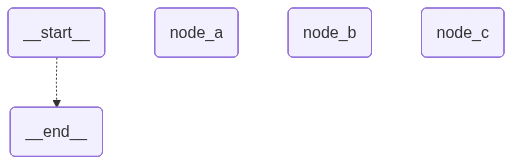

In [1]:
from typing import TypedDict,Literal,Sequence
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem:str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([f"写一首关于{state['topic']}主题的词"]).content
    return {
        "ci_poem": ci_poem
    }

def my_route(state: OverAllState) -> Sequence[Literal["node_a","node_b","node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a","node_c"]
    else:
        return ["node_b","node_c"]


#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_node(node_c)

builder.add_conditional_edges(START,my_route)
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)
builder.add_edge("node_c",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪","content_type":"诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪","content_type":"笑话"})
print(joke_res)

from IPython.display import display
display(graph)
